<a href="https://colab.research.google.com/github/Nakib-Nasrullah/Dengue_Research/blob/main/TimeseriesSplit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imoort libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import xgboost
import tensorflow


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Dengue/Bagerhat_humi_75.csv')

In [ ]:
# Ensure chronological sorting by date
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Define target variable and feature columns
target = "Dengue Case"

In [ ]:
# Exclude non-feature columns, IDs, target derivatives, and parameter-only vectors (like Weight)
drop_cols = [
    "Date",
    "District",
    "Weight",
    "Dengue Case",
    "7-day mean cases",
]
feature_cols = [c for c in df.columns if c not in drop_cols]

In [ ]:
drop_cols = [
    "Date",
    "District",
    "Weight",
    "Dengue Case",
    "7-day mean cases",
]
feature_cols = [c for c in df.columns if c not in drop_cols]

# Drop rows where target or features have missing values (e.g., initial warm-up lag period)
model_df = df.dropna(subset=[target] + feature_cols).copy()

X = model_df[feature_cols]
y = model_df[target]
dates = model_df["Date"]

print(f"Total valid samples for training: {X.shape[0]}")
print(f"Number of features: {len(feature_cols)}")

Total valid samples for training: 1675
Number of features: 24


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Time-Series Cross-Validation (Rolling-Origin Split)
# Prevents temporal leakage by ensuring training always precedes testing in time.
tscv = TimeSeriesSplit(n_splits=5)

fold = 1
rmse_scores = []
mae_scores = []
r2_scores = []

all_y_true = []
all_y_pred = []
all_dates = []

print("\n--- Starting Time-Series Cross-Validation ---")
for train_index, test_index in tscv.split(X):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  test_dates = dates.iloc[test_index]

  # Initialize and train model (RandomForest as a robust baseline; XGBoost/LightGBM can also be used)
  model = RandomForestRegressor(
      n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
  )
  model.fit(X_train, y_train)

  # Predict
  y_pred = model.predict(X_test)

  # Evaluate fold metrics
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  rmse_scores.append(rmse)
  mae_scores.append(mae)
  r2_scores.append(r2)

  all_y_true.extend(y_test)
  all_y_pred.extend(y_pred)
  all_dates.extend(test_dates)

  print(
      f"Fold {fold} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R² Score: {r2:.4f}"
  )
  fold += 1

print("\n--- Cross-Validation Summary ---")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (±{np.std(rmse_scores):.4f})")
print(f"Mean MAE:  {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Mean R²:   {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")

# 3. Feature Importance Analysis (using final fold model)
importances = model.feature_importances_
feature_imp_df = pd.DataFrame(
    {"Feature": feature_cols, "Importance": importances}
).sort_values(by="Importance", ascending=False)

print("\n--- Top 10 Most Important Features ---")
print(feature_imp_df.head(10).to_string(index=False))


--- Starting Time-Series Cross-Validation ---
Fold 1 -> RMSE: 1.9613 | MAE: 1.0494 | R² Score: 0.0182
Fold 2 -> RMSE: 7.9518 | MAE: 4.7067 | R² Score: 0.0322
Fold 3 -> RMSE: 1.5729 | MAE: 0.9610 | R² Score: -0.9168
Fold 4 -> RMSE: 2.8165 | MAE: 1.6502 | R² Score: -0.0930
Fold 5 -> RMSE: 6.6551 | MAE: 3.3255 | R² Score: 0.3149

--- Cross-Validation Summary ---
Mean RMSE: 4.1915 (±2.6050)
Mean MAE:  2.3385 (±1.4571)
Mean R²:   -0.1289 (±0.4163)

--- Top 10 Most Important Features ---
                  Feature  Importance
log(IP+1) × Temp₁₅₋₂₁/100    0.614469
     temperature_2m_mean     0.043236
     Temp_Lagwindow_15–21    0.040219
           Rain_22_28_sum    0.028050
      log(IP+1)×Rain/100​    0.027229
log(IP + 1) × Hum₈₋₁₄/100    0.023750
           Rain_15_21_sum    0.023385
      Temp_Lagwindow_8–14    0.023210
            rain_sum (mm)    0.022107
     Temp_Lagwindow_22–28    0.022077


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Time-Series Cross-Validation (Rolling-Origin Split)
# Prevents temporal leakage by ensuring training always precedes testing in time.
tscv = TimeSeriesSplit(n_splits=5)

fold = 1
rmse_scores = []
mae_scores = []
r2_scores = []

all_y_true = []
all_y_pred = []
all_dates = []

print("\n--- Starting Time-Series Cross-Validation ---")
for train_index, test_index in tscv.split(X):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  test_dates = dates.iloc[test_index]

  # Initialize and train model (RandomForest as a robust baseline; XGBoost/LightGBM can also be used)
  model = RandomForestRegressor(
      n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
  )
  model.fit(X_train, y_train)

  # Predict
  y_pred = model.predict(X_test)

  # Evaluate fold metrics
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  rmse_scores.append(rmse)
  mae_scores.append(mae)
  r2_scores.append(r2)

  all_y_true.extend(y_test)
  all_y_pred.extend(y_pred)
  all_dates.extend(test_dates)

  print(
      f"Fold {fold} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R² Score: {r2:.4f}"
  )
  fold += 1

print("\n--- Cross-Validation Summary ---")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (±{np.std(rmse_scores):.4f})")
print(f"Mean MAE:  {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Mean R²:   {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")

# 3. Feature Importance Analysis (using final fold model)
importances = model.feature_importances_
feature_imp_df = pd.DataFrame(
    {"Feature": feature_cols, "Importance": importances}
).sort_values(by="Importance", ascending=False)

print("\n--- Top 10 Most Important Features ---")
print(feature_imp_df.head(10).to_string(index=False))


--- Starting Time-Series Cross-Validation ---
Fold 1 -> RMSE: 1.9613 | MAE: 1.0494 | R² Score: 0.0182
Fold 2 -> RMSE: 7.9518 | MAE: 4.7067 | R² Score: 0.0322
Fold 3 -> RMSE: 1.5729 | MAE: 0.9610 | R² Score: -0.9168
Fold 4 -> RMSE: 2.8165 | MAE: 1.6502 | R² Score: -0.0930
Fold 5 -> RMSE: 6.6551 | MAE: 3.3255 | R² Score: 0.3149

--- Cross-Validation Summary ---
Mean RMSE: 4.1915 (±2.6050)
Mean MAE:  2.3385 (±1.4571)
Mean R²:   -0.1289 (±0.4163)

--- Top 10 Most Important Features ---
                  Feature  Importance
log(IP+1) × Temp₁₅₋₂₁/100    0.614469
     temperature_2m_mean     0.043236
     Temp_Lagwindow_15–21    0.040219
           Rain_22_28_sum    0.028050
      log(IP+1)×Rain/100​    0.027229
log(IP + 1) × Hum₈₋₁₄/100    0.023750
           Rain_15_21_sum    0.023385
      Temp_Lagwindow_8–14    0.023210
            rain_sum (mm)    0.022107
     Temp_Lagwindow_22–28    0.022077



Saved performance plot as 'dengue_prediction_results.png'


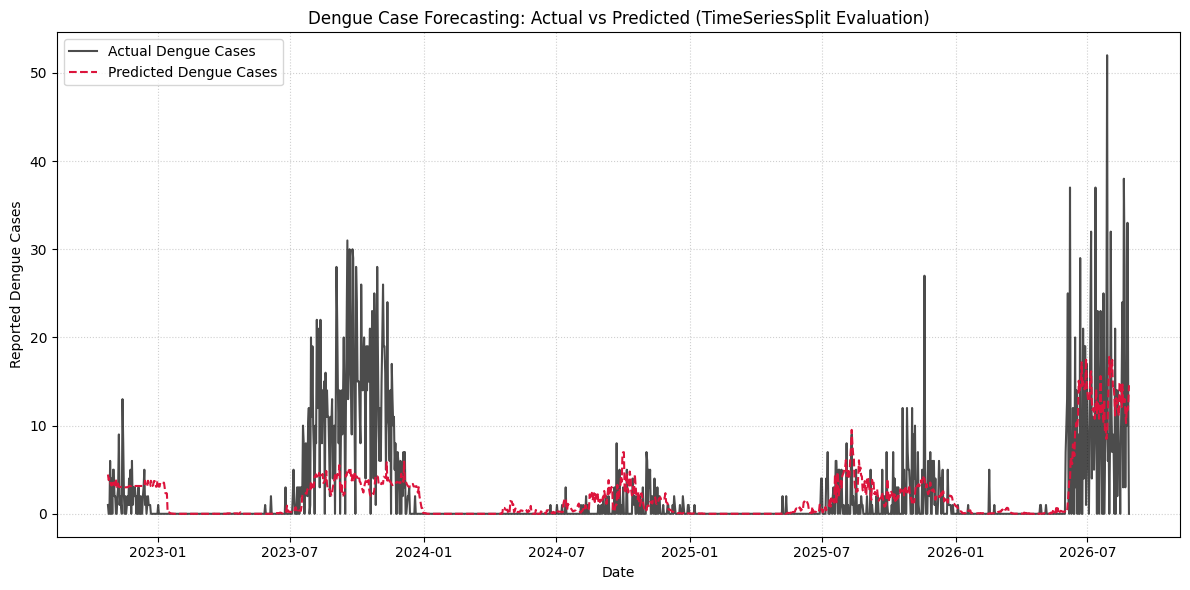

In [ ]:
# 4. Visualization: Actual vs Predicted Over Time
plt.figure(figsize=(12, 6))
plt.plot(all_dates, all_y_true, label="Actual Dengue Cases", color="black", alpha=0.7)
plt.plot(
    all_dates,
    all_y_pred,
    label="Predicted Dengue Cases",
    color="crimson",
    linestyle="--",
)
plt.title(
    "Dengue Case Forecasting: Actual vs Predicted (TimeSeriesSplit Evaluation)"
)
plt.xlabel("Date")
plt.ylabel("Reported Dengue Cases")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig("dengue_prediction_results.png", dpi=300)
print("\nSaved performance plot as 'dengue_prediction_results.png'")
plt.show()